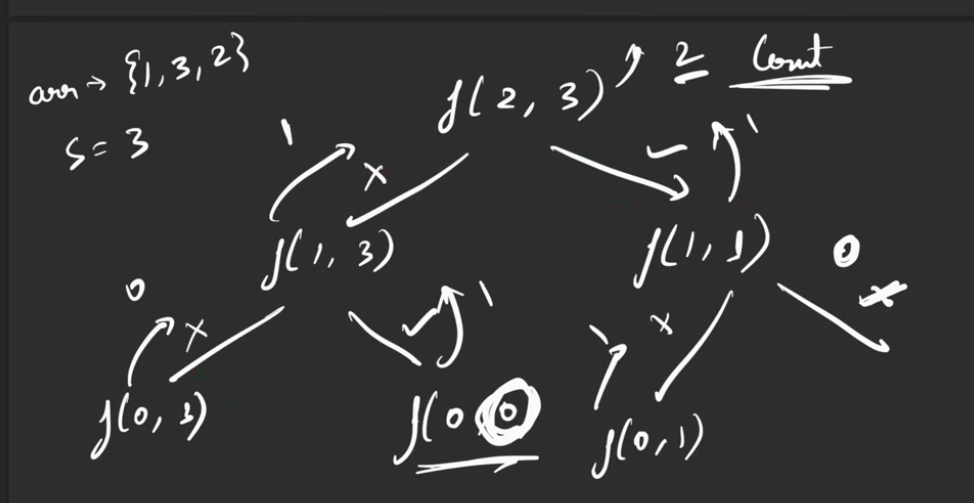

In [1]:
# Recursion
from typing import List

def solve(index,target,nums):
    if target == 0:
        return 1
    
    if index == 0:
        return 1 if nums[0] == target else 0

    notTake = solve(index-1,target,nums)
    take = 0
    if nums[index] <= target:
        take = solve(index-1,target-nums[index],nums)
    
    return take + notTake
def findWays(arr: List[int], k: int) -> int:
    # Write your code here.
    return solve(len(arr)-1,k,arr)

In [18]:
# Memoization
# TC :- O(N * Sum)
# TC :- O(N * Sum) + O(N)
from typing import List

def solve(index,target,nums,dp):
    if target == 0:
        return 1
    
    if index == 0:
        return 1 if nums[0] == target else 0
    
    if index == 0:
        if target == 0 and nums[0] == 0:
            return 2 
        if target == 0 or target == nums[0]:
            return 1
    
    if dp[index][target] != -1:
        return dp[index][target]

    notTake = solve(index-1,target,nums,dp)
    take = 0
    if nums[index] <= target:
        take = solve(index-1,target-nums[index],nums,dp)
    
    dp[index][target] = take + notTake
    return dp[index][target]

def findWays(arr: List[int], k: int) -> int:
    # Write your code here.
    dp = [[-1] * (k + 1) for _ in range(len(arr))]
    return solve(len(arr)-1,k,arr,dp)


# Driver code
nums = [1, 2, 3, 3]
target = 6
print(findWays(nums, target))

3


In [10]:
# Tabulation
# 1. Write base case
# 2. Look at the changing param and write nested loop
# 3. Copy recursion

class Solution:
    def countSubsets(self, arr, K):
        # Get number of elements
        n = len(arr)

        # Create dp table with dimensions n x (K+1)
        dp = [[0] * (K + 1) for _ in range(n)]

        # Base case: one subset (empty set) makes sum 0
        dp[0][0] = 1

        # If first element is <= K, mark dp[0][arr[0]] as 1
        if arr[0] <= K:
            dp[0][arr[0]] = 1

        # Fill the table
        for i in range(1, n):
            for target in range(K + 1):
                # Exclude current element
                notTake = dp[i - 1][target]

                # Include current element if possible
                take = 0
                if arr[i] <= target:
                    take = dp[i - 1][target - arr[i]]

                # Total ways
                dp[i][target] = notTake + take

        # Final answer
        return dp[n - 1][K]


# Driver code
arr = [1, 2, 3, 3]
K = 6
obj = Solution()
print(obj.countSubsets(arr, K))


3


In [ ]:
# Space Optimization
class Solution:
    def countSubsets(self, arr, K):
        prev = [0] * (K + 1)
        prev[0] = 1

        if arr[0] <= K:
            prev[arr[0]] += 1
        
        

        for i in range(1, len(arr)):
            curr = [0] * (K + 1)
            curr[0] = 1

            for summ in range(K + 1):
                notTake = prev[summ]

                take = 0
                if arr[i] <= summ:
                    take = prev[summ - arr[i]]

                curr[summ] = notTake + take

            prev = curr

        return prev[K]


# Driver code
arr = [1, 2, 3, 3]
K = 6

obj = Solution()
print(obj.countSubsets(arr, K))

3
